##**[13주차]실습**
- 교재를 참고하여 아래의 실습1), 실습2)를 수행하시오.
- 모든 코드의 결과를 출력하여, 과제 **[13주차]/[13주차]실습**에 제출하시오.

In [1]:
print("2353881", "최대영")

2353881 최대영


In [3]:
from google.colab import auth

auth.authenticate_user()
!gcloud config get-value account

tigers7101@gmail.com


###**예제 1) 순방향 확산 모델**
- **[실습목표]** 2차원 이미지를 읽어서 순방향 확산을 구현하는 예제를 수행한다.
- 본 예제에서는 **dog.jpg** 이미지를 읽고, 순방향 확산 과정에서 이미지에 점진적으로 노이즈를 추가하는 과정을 구현한다.
- 간단한 구현을 위해 베타 스케줄링은 생략된다.

In [4]:
# 필요한 모듈 import
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [5]:
# 노이즈 추가 함수 add_noise()함수를 정의
# 노이즈의 크기는 noise_level로 조절됨

def add_noise(image, noise_level):
  # 1. 이미지와 동일한 크기의 가우시안 노이즈 생성
  noise = np.random.normal(0, noise_level, image.shape)
  # 2. 원본 이미지에 노이즈를 더함
  noisy_image = image + noise
  # 3. 픽셀 값이 0~255 범위를 벗어나지 않도록 클리핑 후 uint8 타입으로 변환
  noise_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
  return noise_image

In [6]:
# 순방향 확산 함수 forward_diffusion() 함수를 정의
# forward_diffusion(): 이미지에 점진적으로 노이즈를 추가하여 여러 단계의 노이즈 이미지를 생성하는 함수
def forward_diffusion(image, num_steps):
  # 0부터 시작하여 num_steps 단계만큼 점진적으로 증가하는 노이즈 레벨 생성 (예: 0에서 100까지)
  noise_levels = np.linspace(0, 100, num_steps)
  noisy_images = []
  for noise_level in noise_levels:
    # 이전 단계에서 정의한 add_noise 함수를 호출하여 노이즈가 추가된 이미지 생성
    noisy_image = add_noise(image, noise_level)
    noisy_images.append(noisy_image)

  return noisy_images

In [22]:
# 1. 구글 드라이브 마운트 (이 주소는 고정입니다)
from google.colab import drive
drive.mount('/content/drive')

# 2. 내 드라이브 안에서 dog.jpg 실제 경로 찾기
!find /content/drive -name "dog.jpg"

Mounted at /content/drive
/content/drive/MyDrive/dog.jpg


In [24]:
# OpenCV를 사용하여 이미지를 그레이스케일 이미지로 읽어 image에 저장
# 데이터 타입은 float32로 변환
image_path = "/content/drive/MyDrive/dog.jpg" #path 수정
# 이미지를 그레이스케일(흑백)로 로드
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
# 연산의 정밀도를 위해 float32 타입으로 변환
image = image.astype(np.float32)

In [25]:
# forward_diffusion() 함수를 호출하여 여러 단계의 노이즈 이미지를 생성
num_steps = 10
noisy_images = forward_diffusion(image, num_steps) # 정의해둔 순방향 확산 함수에 전처리된 image와 단계수(10)를 전달합니다.

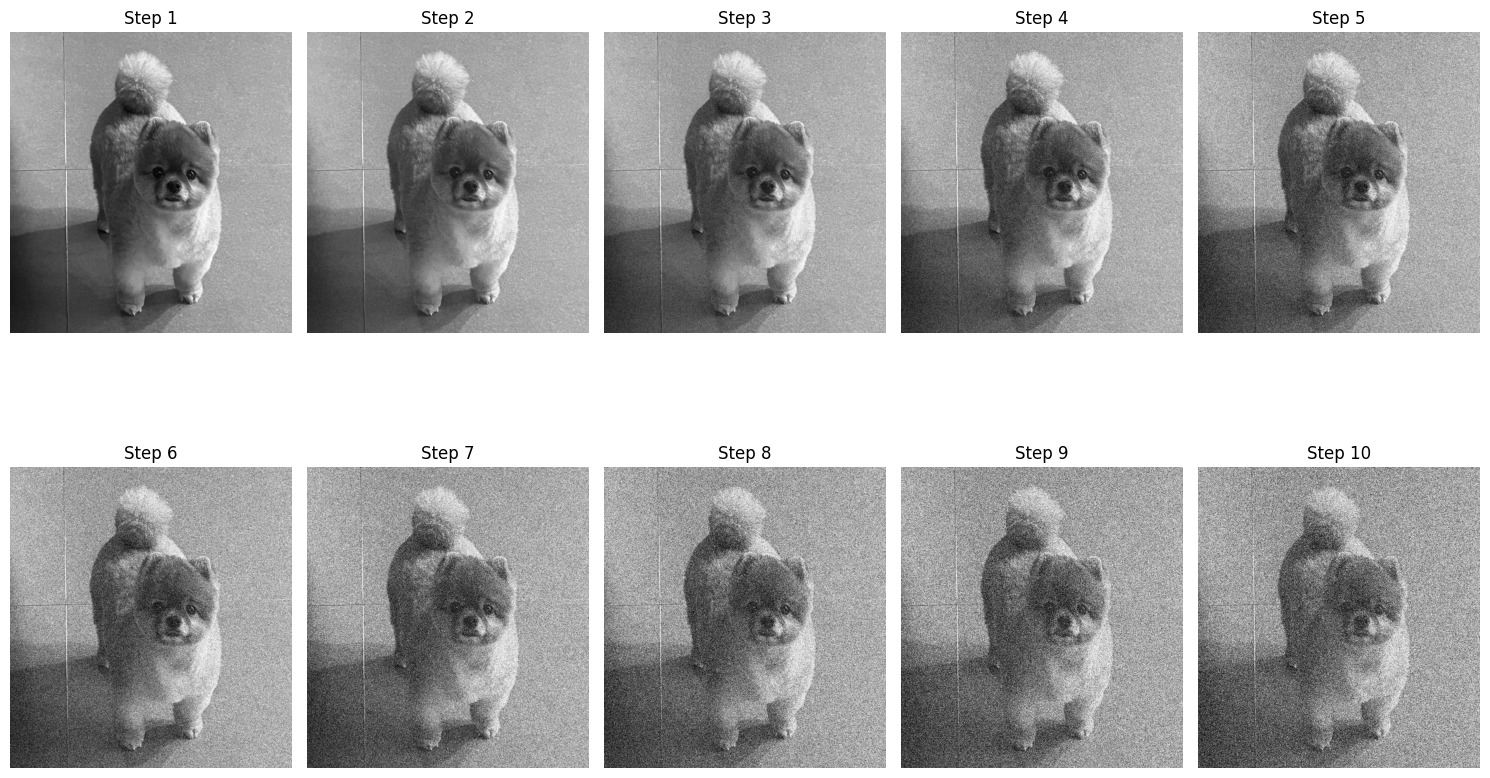

In [26]:
# Matplotlib를 사용하여 각 단계별 노이즈 이미지를 시각화
plt.figure(figsize=(15,10))
for i, noisy_image in enumerate(noisy_images):
  plt.subplot(2, 5, i+1)
  plt.imshow(noisy_image, cmap='gray')
  plt.title(f'Step {i+1}')
  plt.axis('off')
plt.tight_layout()
plt.show()

###**예제 2) 역방향 확산**
- **[실습목표]** 원본 데이터에 노이즈를 추가한 후, 원본 데이터를 복원하는 과정
- 순방향 확산 과정에서 노이즈가 추가된 데이터를 입력으로 받아 원본 데이터를 복원하는 것을 목표로 함


In [27]:
# 필요한 모듈 import
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [28]:
# 노이즈 추가 함수
def add_noise(image, noise_level):
  noise = np.random.normal(0, noise_level, image.shape)
  noisy_image = image + noise
  noise_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
  return noise_image

In [37]:
# 순방향 확산 함수
def forward_diffusion(image, num_steps):
  noise_levels = np.linspace(0, 100, num_steps)
  noisy_images = []
  for noise_level in noise_levels:
    noisy_image = add_noise(image, noise_level)
    noisy_images.append(noisy_image)
  return noisy_images

In [38]:
# 이미지 읽기
image_path = "/content/drive/MyDrive/dog.jpg" #path 수정
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)

In [39]:
# 이미지 크기 조절
target_size = (256, 256)
image = cv2.resize(image, target_size)

In [40]:
# 순방향 확산 과정 수행
num_steps = 10
noisy_images = forward_diffusion(image, num_steps)

In [60]:
# U-Net 모델 정의
def build_unet(input_shape):
  # 1. 입력 레이어 정의 (shape 받아오기)
  inputs = layers.Input(shape=input_shape)

  # 인코더
  # 툴팁에 가려진 부분은 보통 인코더 레이어들이 위치합니다.
  c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
  p1 = layers.MaxPooling2D((2, 2))(c1)

  c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)

  # 디코더
  # 2. 업샘플링 및 스킵 커넥션 결합 연산 수행
  u3 = layers.UpSampling2D((2, 2))(c2)
    # 인코더의 특성 맵(c1)과 업샘플링된 맵(u3)을 병합(Skip Connection)
  concat3 = layers.Concatenate()([u3, c1])
  c3 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(concat3)

  outputs = layers.Conv2D(1, (1, 1), padding='same')(c3)

  model = Model(inputs, outputs)
  return model

In [61]:
from tensorflow.keras import layers, Model

input_shape = (256, 256, 1)
model = build_unet(input_shape)

In [62]:
# 모델 컴파일
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 학습 데이터 준비, 노이즈가 있는 영상과 없는 영상으로 학습을 수행
noisy_images_tensor = np.array(noisy_images, dtype=np.float32)

original_image_tensor = np.array([image] * num_steps, dtype=np.float32)

In [63]:
# 모델 학습 (실습 시간에는 epoch을 10으로 줄여서 수행)
num_epochs = 10
model.fit(noisy_images_tensor, original_image_tensor, epochs=num_epochs)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 22828.6348 - mae: 143.6808
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 9869.3184 - mae: 92.6469
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 3525.7681 - mae: 52.7594
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 806.6779 - mae: 22.8351
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 1747.5453 - mae: 34.3827
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 3059.3196 - mae: 49.2009
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 2757.1353 - mae: 46.5669
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 1819.0778 - mae: 36.3267
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 1016.1320 - mae: 24.9115
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 590.4288 - mae: 17.8725


In [64]:
# 모델 평가
# 학습된 U-Net 모델에 노이즈 이미지 텐서를 입력하여 노이즈가 제거된 이미지를 예측(생성)합니다.
denoised_image = model.predict(noisy_images_tensor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


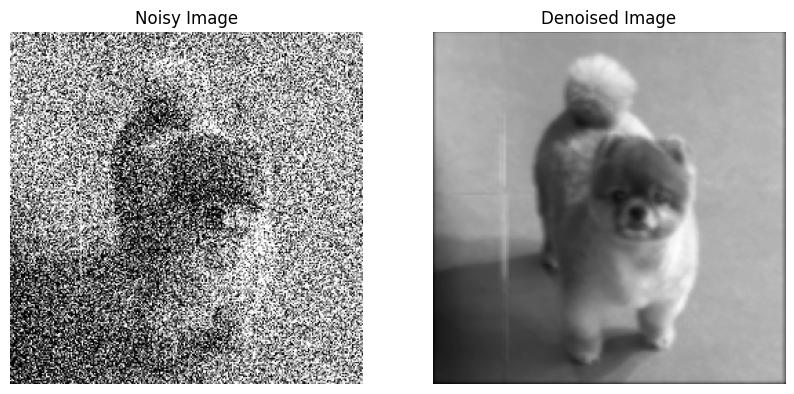

In [67]:
# 모델 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(noisy_images[-1], cmap='gray')
plt.title('Noisy Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(denoised_image[0].squeeze().astype(np.uint8), cmap='gray')
plt.title('Denoised Image')
plt.axis('off')
plt.show()